In [ ]:
"""
Script to segment the data from 'final_products' into one square kilometer
tracts, on which the workflow (subsequent sections) was designed to operate
"""

import os
import numpy as np
import cv2
from osgeo import gdal
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Define paths
final_products_path = '/content/drive/My Drive/final_products'
workspace_path = '/content/drive/My Drive/Workspace'

# Helper function to create directories
def ensure_dir(directory):
    if not os.path.exists(directory):
        os.makedirs(directory)

# Helper function to read GeoTIFF
def read_geotiff(filepath):
    dataset = gdal.Open(filepath)
    if dataset is None:
        raise FileNotFoundError(f"File not found: {filepath}")
    array = dataset.ReadAsArray()
    transform = dataset.GetGeoTransform()
    return array, transform

# Helper function to save GeoTIFF
def save_geotiff(filepath, array, transform, projection):
    driver = gdal.GetDriverByName('GTiff')
    rows, cols = array.shape
    dataset = driver.Create(filepath, cols, rows, 1, gdal.GDT_UInt16)
    dataset.SetGeoTransform(transform)
    dataset.SetProjection(projection)
    dataset.GetRasterBand(1).WriteArray(array)
    dataset.FlushCache()
    dataset = None

# Loop through survey areas
sites = [d for d in os.listdir(os.path.join(final_products_path, 'imagery')) if os.path.isdir(os.path.join(final_products_path, 'imagery', d))]

for k, site in enumerate(sites):
    # Generate list of dates
    imagery_path = os.path.join(final_products_path, 'imagery', site)
    dates = [f[:-4] for f in os.listdir(imagery_path) if f.endswith('.tif')]

    # Find site bounding box
    first_image_path = os.path.join(imagery_path, f"{dates[0]}.tif")
    _, transform = read_geotiff(first_image_path)
    bbox = [[transform[0], transform[3]], [transform[0] + transform[1] * 1000, transform[3] + transform[5] * 1000]]
    e0 = np.arange(bbox[0][0] / 1000, bbox[1][0] / 1000, 1).astype(int).astype(str)
    n0 = np.arange(bbox[0][1] / 1000, bbox[1][1] / 1000, -1).astype(int).astype(str)

    for date in dates:
        # Read and pad images
        image_path = os.path.join(imagery_path, f"{date}.tif")
        pool_path = os.path.join(final_products_path, 'pools_raster', site, f"{date}.tif")

        wvimg, _ = read_geotiff(image_path)
        pools, _ = read_geotiff(pool_path)

        wvimg = np.pad(wvimg, ((28, 28), (28, 28)), mode='symmetric')
        pools = np.pad(pools, ((28, 28), (28, 28)), mode='symmetric')

        for i, n in enumerate(n0):
            for j, e in enumerate(e0):
                sqkm = f"{e}_{n}"

                # Ensure directories exist
                imagery_tile_dir = os.path.join(workspace_path, 'imagery', site, sqkm)
                pools_tile_dir = os.path.join(workspace_path, 'results', 'post_CRF', site, sqkm)
                ensure_dir(imagery_tile_dir)
                ensure_dir(pools_tile_dir)

                # Extract tiles
                wvimg_tile = wvimg[i * 2000:(i + 1) * 2000 + 56, j * 2000:(j + 1) * 2000 + 56]
                pools_tile = pools[i * 2000 + 28:(i + 1) * 2000 + 28, j * 2000 + 28:(j + 1) * 2000 + 28]

                # Save tiles
                wvimg_tile_path = os.path.join(imagery_tile_dir, f"{date}.tif")
                pools_tile_path = os.path.join(pools_tile_dir, f"{date}.tif")
                save_geotiff(wvimg_tile_path, wvimg_tile, transform, gdal.Open(image_path).GetProjection())
                save_geotiff(pools_tile_path, pools_tile, transform, gdal.Open(pool_path).GetProjection())

    print(f"Done unpacking imagery from {k + 1} of {len(sites)} sites! ({site})")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Done unpacking imagery from 1 of 27 sites! (prudhoe)
Done unpacking imagery from 2 of 27 sites! (yana)
Done unpacking imagery from 3 of 27 sites! (wrangel)
Done unpacking imagery from 4 of 27 sites! (utqiagvik)
Done unpacking imagery from 5 of 27 sites! (yamal)
Done unpacking imagery from 6 of 27 sites! (tapkaurak)
Done unpacking imagery from 7 of 27 sites! (taymyr)
Done unpacking imagery from 8 of 27 sites! (samoylov)
Done unpacking imagery from 9 of 27 sites! (kurungnakh)
Done unpacking imagery from 10 of 27 sites! (nechilik)
Done unpacking imagery from 11 of 27 sites! (kolyma)
Done unpacking imagery from 12 of 27 sites! (kuparuk)
Done unpacking imagery from 13 of 27 sites! (herschel)
Done unpacking imagery from 14 of 27 sites! (icycape)
Done unpacking imagery from 15 of 27 sites! (ikpikpuk)
Done unpacking imagery from 16 of 27 sites! (khatanga)
Done unpack

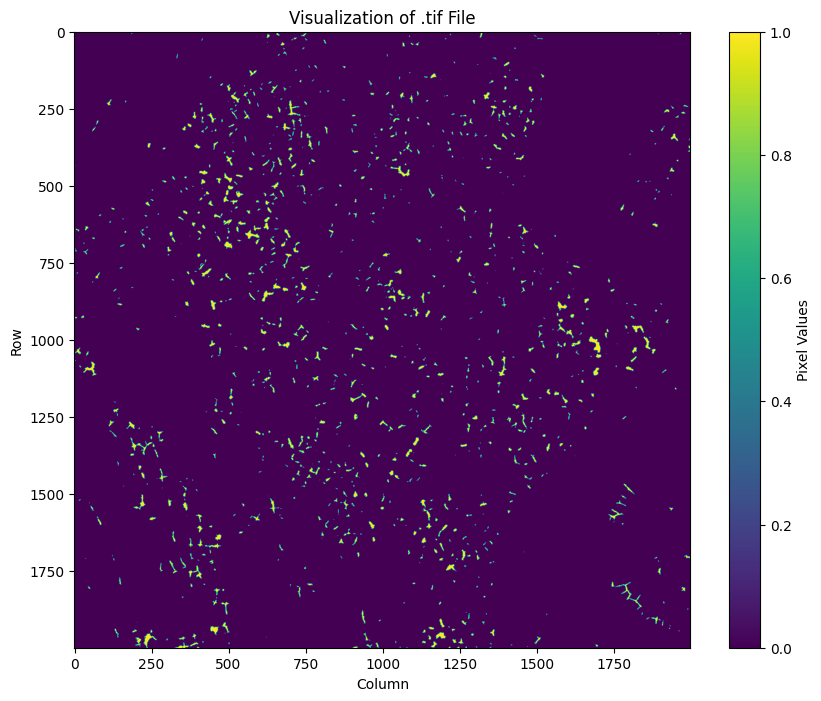

In [ ]:
import rasterio
import matplotlib.pyplot as plt

# Path to your .tif file
tif_file = '/content/2011-07-02.tif'

# Open the .tif file
with rasterio.open(tif_file) as src:
    # Read the data
    data = src.read(1)  # Reading the first band; adjust as needed for multi-band images
    # Get metadata
    meta = src.meta

# Plot the .tif data
plt.figure(figsize=(10, 8))
plt.imshow(data, cmap='viridis')  # Adjust the colormap as needed
plt.colorbar(label='Pixel Values')
plt.title('Visualization of .tif File')
plt.xlabel('Column')
plt.ylabel('Row')
plt.show()

In [ ]:
"""
Script to train a generalized UNet using imagery from Prudhoe Bay, Kuparuk,
and Wrangel Island
"""

import os
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import Sequence
from sklearn.model_selection import train_test_split
from albumentations import Compose, HorizontalFlip, VerticalFlip
import numpy as np
import matplotlib.pyplot as plt
import cv2
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Define paths
data_path = '/content/drive/My Drive/training_data'
imagery_path = os.path.join(data_path, 'imagery')
pools_path = os.path.join(data_path, 'pools')

# Helper function to load images and masks
def load_images_and_masks(image_paths, mask_paths):
    images, masks = [], []
    for img_path, mask_path in zip(image_paths, mask_paths):
        img = cv2.imread(img_path, cv2.IMREAD_COLOR)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        images.append(img)
        masks.append(mask)
    return np.array(images), np.array(masks)

# Load data
prudhoe_images = [os.path.join(imagery_path, f) for f in os.listdir(imagery_path) if 'prudhoe' in f]
prudhoe_masks = [os.path.join(pools_path, f) for f in os.listdir(pools_path) if 'prudhoe' in f]
kuparuk_images = [os.path.join(imagery_path, f) for f in os.listdir(imagery_path) if 'kuparuk' in f]
kuparuk_masks = [os.path.join(pools_path, f) for f in os.listdir(pools_path) if 'kuparuk' in f]
wrangel_images = [os.path.join(imagery_path, f) for f in os.listdir(imagery_path) if 'wrangel' in f]
wrangel_masks = [os.path.join(pools_path, f) for f in os.listdir(pools_path) if 'wrangel' in f]

all_images = prudhoe_images + kuparuk_images + wrangel_images
all_masks = prudhoe_masks + kuparuk_masks + wrangel_masks

images, masks = load_images_and_masks(all_images, all_masks)

# Preprocess masks to binary
masks = (masks == 255).astype(np.uint8)

# Data augmentation
def augment_images(images, masks):
    augmentor = Compose([
        HorizontalFlip(p=0.5),
        VerticalFlip(p=0.5)
    ])
    aug_images, aug_masks = [], []
    for img, mask in zip(images, masks):
        augmented = augmentor(image=img, mask=mask)
        aug_images.append(augmented['image'])
        aug_masks.append(augmented['mask'])
    return np.array(aug_images), np.array(aug_masks)

# Split data into training and validation
train_images, val_images, train_masks, val_masks = train_test_split(images, masks, test_size=0.1, random_state=42)

# Define U-Net model
def unet(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)

    # Encoder
    c1 = layers.Conv2D(16, (3, 3), activation='relu', padding='same')(inputs)
    c1 = layers.Conv2D(16, (3, 3), activation='relu', padding='same')(c1)
    p1 = layers.MaxPooling2D((2, 2))(c1)

    c2 = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(p1)
    c2 = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(c2)
    p2 = layers.MaxPooling2D((2, 2))(c2)

    c3 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(p2)
    c3 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(c3)
    p3 = layers.MaxPooling2D((2, 2))(c3)

    c4 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(p3)
    c4 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(c4)
    p4 = layers.MaxPooling2D((2, 2))(c4)

    # Bottleneck
    c5 = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(p4)
    c5 = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(c5)

    # Decoder
    u6 = layers.Conv2DTranspose(128, (2, 2), strides=(2, 2), padding='same')(c5)
    u6 = layers.concatenate([u6, c4])
    c6 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(u6)
    c6 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(c6)

    u7 = layers.Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same')(c6)
    u7 = layers.concatenate([u7, c3])
    c7 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(u7)
    c7 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(c7)

    u8 = layers.Conv2DTranspose(32, (2, 2), strides=(2, 2), padding='same')(c7)
    u8 = layers.concatenate([u8, c2])
    c8 = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(u8)
    c8 = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(c8)

    u9 = layers.Conv2DTranspose(16, (2, 2), strides=(2, 2), padding='same')(c8)
    u9 = layers.concatenate([u9, c1])
    c9 = layers.Conv2D(16, (3, 3), activation='relu', padding='same')(u9)
    c9 = layers.Conv2D(16, (3, 3), activation='relu', padding='same')(c9)

    outputs = layers.Conv2D(num_classes, (1, 1), activation='softmax')(c9)

    model = models.Model(inputs, outputs)
    return model

# Instantiate model
input_shape = (256, 256, 3)
num_classes = 2
model = unet(input_shape, num_classes)

# Compile model
model.compile(optimizer=Adam(learning_rate=1e-4), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train model
history = model.fit(
    train_images, train_masks,
    validation_data=(val_images, val_masks),
    epochs=7,
    batch_size=1,
    shuffle=True,
    verbose=1
)

#Saving model
model.save('/content/drive/My Drive/Workspace/trainedUNet-general.h5')

/usr/local/lib/python3.10/dist-packages/albumentations/__init__.py:24: UserWarning: A new version of Albumentations is available: 1.4.24 (you have 1.4.20). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


Mounted at /content/drive
Epoch 1/7
2700/2700 ━━━━━━━━━━━━━━━━━━━━ 2286s 843ms/step - accuracy: 0.9598 - loss: 0.5047 - val_accuracy: 0.9915 - val_loss: 0.0647
Epoch 2/7
2700/2700 ━━━━━━━━━━━━━━━━━━━━ 2259s 837ms/step - accuracy: 0.9917 - loss: 0.0610 - val_accuracy: 0.9921 - val_loss: 0.0604
Epoch 3/7
2700/2700 ━━━━━━━━━━━━━━━━━━━━ 2317s 842ms/step - accuracy: 0.9915 - loss: 0.0584 - val_accuracy: 0.9922 - val_loss: 0.0497
Epoch 4/7
2700/2700 ━━━━━━━━━━━━━━━━━━━━ 2319s 859ms/step - accuracy: 0.9920 - loss: 0.0535 - val_accuracy: 0.9922 - val_loss: 0.0507
Epoch 5/7
2700/2700 ━━━━━━━━━━━━━━━━━━━━ 2320s 843ms/step - accuracy: 0.9923 - loss: 0.0497 - val_accuracy: 0.9922 - val_loss: 0.0488
Epoch 6/7
2700/2700 ━━━━━━━━━━━━━━━━━━━━ 2293s 849ms/step - accuracy: 0.9918 - loss: 0.0515 - val_accuracy: 0.9922 - val_loss: 0.0446
Epoch 7/7
2700/2700 ━━━━━━━━━━━━━━━━━━━━ 2299s 852ms/step - accuracy: 0.9924 - loss: 0.0449 - val_accuracy: 0.9922 - val_loss: 0.0440


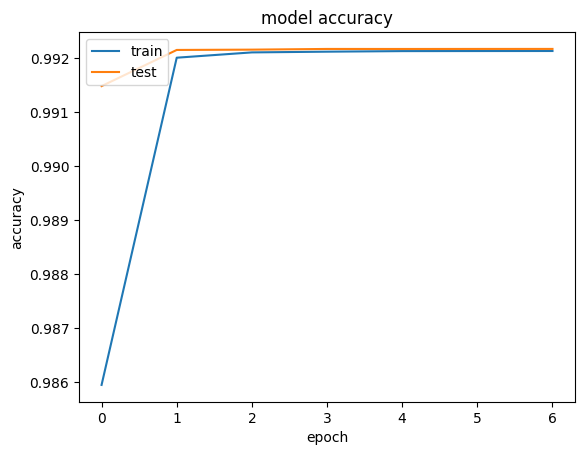

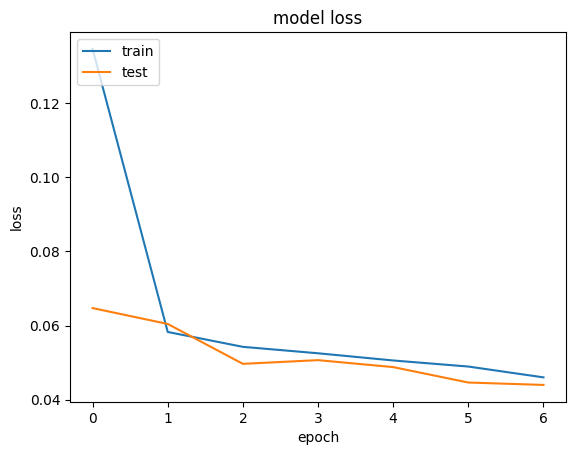

In [ ]:
# summarize history for accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()
# summarize history for loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()